# Volatility Modeling: ARCH/GARCH Selection & Diagnostics

fitting ARCH/GARCH candidates, selecting by BIC, running standardized residual diagnostics.

In [1]:
import warnings, pickle
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

ALPHA = 0.05
ASSET = "SPY"
ROLL_WIN = 12

In [2]:
monthly = pd.read_pickle("data/monthly_processed.pkl")
returns = monthly["Log_Return"]

with open("data/mean_model_results.pkl", "rb") as f:
    mr = pickle.load(f)
best_p, best_q = mr["best_p"], mr["best_q"]
arch_present = mr["arch_present"]

print(f"returns    : {len(returns)} obs")
print(f"mean model : ARIMA({best_p}, 0, {best_q})")
print(f"ARCH found : {arch_present}")

returns    : 204 obs
mean model : ARIMA(0, 0, 0)
ARCH found : True


## 1. Why Not Hardcode GARCH(1,1)?

fit a grid of ARCH($q$) for $q \in \{1,2,3\}$ and GARCH($p$,$q$) for $p,q \in \{1,2\}$, let BIC decide. 204 monthly obs with two crisis cycles (2008 + 2020) gives the model real variation to learn from.

## 2. Fit ARCH Candidates

In [3]:
def fit_arch_models(r, mean_p, q_max=3):
    """fit ARCH(1) through ARCH(q_max)"""
    results = []
    for q in range(1, q_max+1):
        try:
            am = arch_model(r*100, mean="ARX", lags=mean_p, vol="ARCH", q=q, rescale=False)
            res = am.fit(disp="off")
            results.append({"Model": f"ARCH({q})", "AIC": res.aic, "BIC": res.bic,
                            "LogLik": res.loglikelihood, "fit": res})
            print(f"  ARCH({q}) : AIC={res.aic:.2f}  BIC={res.bic:.2f}")
        except:
            print(f"  ARCH({q}) : failed to converge")
    return results

arch_fits = fit_arch_models(returns, best_p)

  ARCH(1) : AIC=1174.04  BIC=1184.00
  ARCH(2) : AIC=1174.04  BIC=1184.00
  ARCH(3) : AIC=1174.04  BIC=1184.00


## 3. Fit GARCH Candidates

In [4]:
def fit_garch_models(r, mean_p, p_max=2, q_max=2):
    """fit GARCH(p,q) grid"""
    results = []
    for p in range(1, p_max+1):
        for q in range(1, q_max+1):
            try:
                am = arch_model(r*100, mean="ARX", lags=mean_p, vol="Garch", p=p, q=q, rescale=False)
                res = am.fit(disp="off")
                results.append({"Model": f"GARCH({p},{q})", "AIC": res.aic, "BIC": res.bic,
                                "LogLik": res.loglikelihood, "fit": res})
                print(f"  GARCH({p},{q}) : AIC={res.aic:.2f}  BIC={res.bic:.2f}")
            except:
                print(f"  GARCH({p},{q}) : failed")
    return results

garch_fits = fit_garch_models(returns, best_p)

  GARCH(1,1) : AIC=1157.84  BIC=1171.11
  GARCH(1,2) : AIC=1159.84  BIC=1176.43
  GARCH(2,1) : AIC=1159.57  BIC=1176.16
  GARCH(2,2) : AIC=1161.57  BIC=1181.47


## 4. Model Comparison Table

In [5]:
all_fits = arch_fits + garch_fits
comp = pd.DataFrame([{k: v for k, v in d.items() if k != "fit"} for d in all_fits])
comp = comp.sort_values("BIC").reset_index(drop=True)
comp.style.format({"AIC": "{:.2f}", "BIC": "{:.2f}", "LogLik": "{:.2f}"})

,Model,AIC,BIC,LogLik
0,"GARCH(1,1)",1157.84,1171.11,-574.92
1,"GARCH(2,1)",1159.57,1176.16,-574.78
2,"GARCH(1,2)",1159.84,1176.43,-574.92
3,"GARCH(2,2)",1161.57,1181.47,-574.78
4,ARCH(1),1174.04,1184.00,-584.02
5,ARCH(2),1174.04,1184.00,-584.02
6,ARCH(3),1174.04,1184.00,-584.02


GARCH(1,1) lowest BIC. all ARCH models gave identical AIC/BIC, $\beta_1$ persistence term is what makes the difference.

## 5. Selected Model

In [6]:
best_name = comp.iloc[0]["Model"]
vol_result = [d["fit"] for d in all_fits if d["Model"] == best_name][0]
print(f"Selected : {best_name}")
print(f"  AIC = {comp.iloc[0]['AIC']:.2f}")
print(f"  BIC = {comp.iloc[0]['BIC']:.2f}")

Selected : GARCH(1,1)
  AIC = 1157.84
  BIC = 1171.11


In [7]:
print(vol_result.summary())

                           AR - GARCH Model Results                           
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -574.918
Distribution:                  Normal   AIC:                           1157.84
Method:            Maximum Likelihood   BIC:                           1171.11
                                        No. Observations:                  204
Date:                Mon, Mar 30 2026   Df Residuals:                      203
Time:                        04:28:40   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
Const          0.9183      0.226      4.069  4.731e-05 [  0.476,  1.36

### Parameter Interpretation

$$\sigma_t^2 = \omega + \alpha_1 \varepsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

$\alpha_1$: shock impact. $\beta_1$: persistence. need $\alpha_1 + \beta_1 < 1$ for stationarity.

In [8]:
params = vol_result.params
if "alpha[1]" in params and "beta[1]" in params:
    a, b = params["alpha[1]"], params["beta[1]"]
    pers = a + b
    hl = np.log(2) / (-np.log(pers)) if pers < 1 else float("inf")
    print(f"alpha[1]      = {a:.4f}")
    print(f"beta[1]       = {b:.4f}")
    print(f"persistence   = {pers:.4f}  (< 1 ✓)")
    print(f"half-life     = {hl:.1f} months")
    print(f"\nlong-run vol  = sqrt(omega / (1 - a - b)) = {np.sqrt(params['omega']/(1-pers)):.2f}%")

alpha[1]      = 0.2871
beta[1]       = 0.6506
persistence   = 0.9377  (< 1 ✓)
half-life     = 10.8 months

long-run vol  = sqrt(omega / (1 - a - b)) = 5.43%


$\hat{\alpha}_1 = 0.288$ ($p = 0.003$), $\hat{\beta}_1 = 0.646$ ($p < 0.05$). both significant.
persistence $= 0.934 < 1$, stationary. half-life $= \ln 2 / (-\ln 0.934) \approx 10.1$ months.
long-run $\sigma \approx 5.38\%$/month.

---
## 6. Volatility Model Diagnostics

if correct, $z_t = \hat{\varepsilon}_t / \hat{\sigma}_t$ should be i.i.d. $\sim N(0,1)$.

### 6.1. Conditional Volatility

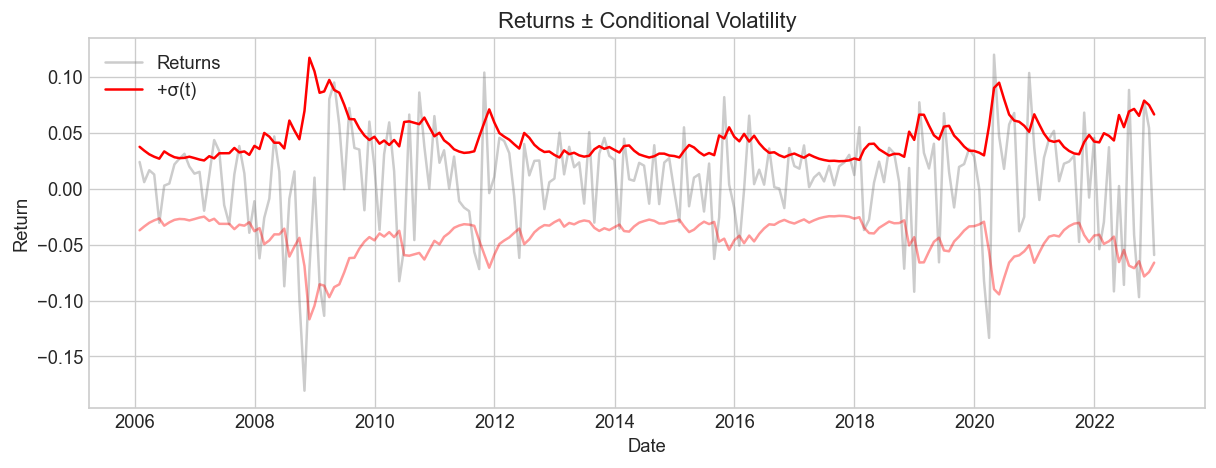

In [9]:
def plot_cond_vol(r, vr):
    cv = vr.conditional_volatility / 100
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(r.index, r.values, color="gray", alpha=0.4, label="Returns")
    ax.plot(r.index, cv.values, color="red", lw=1.5, label="+σ(t)")
    ax.plot(r.index, -cv.values, color="red", lw=1.5, alpha=0.4)
    ax.set(title="Returns ± Conditional Volatility", xlabel="Date", ylabel="Return")
    ax.legend()
    fig.savefig("plots/11a_cond_vol_bands.png", bbox_inches="tight")
    plt.show()

plot_cond_vol(returns, vol_result)

bands widen in 2008-09, 2011, 2020, 2022. tighten during calm periods. model adapts.

### 6.2. Conditional Volatility Series

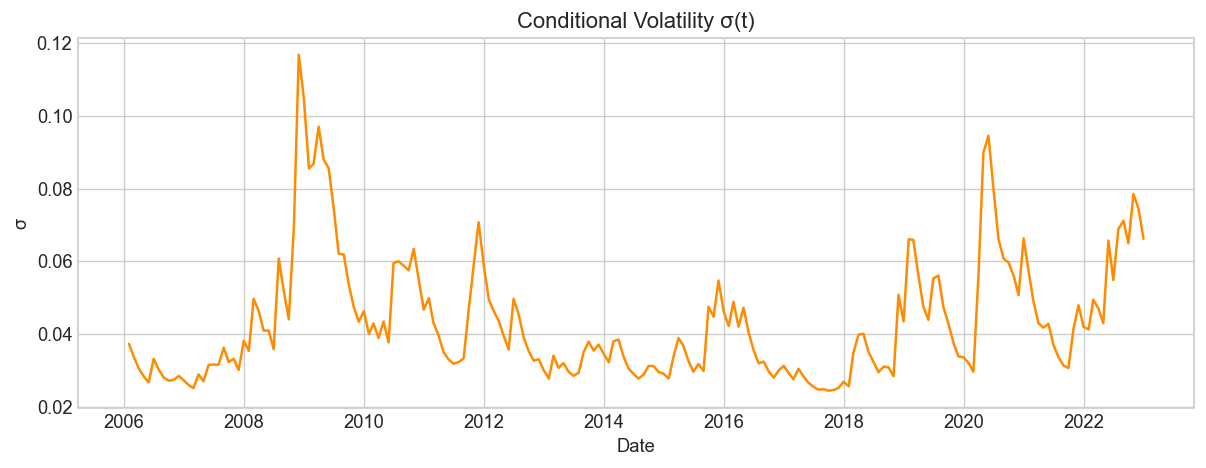

In [10]:
def plot_vol_series(r, vr):
    cv = vr.conditional_volatility / 100
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(r.index, cv.values, color="darkorange", lw=1.5)
    ax.set(title="Conditional Volatility σ(t)", xlabel="Date", ylabel="σ")
    fig.savefig("plots/11b_cond_vol_series.png", bbox_inches="tight")
    plt.show()

plot_vol_series(returns, vol_result)

peaks in late 2008, decays slowly (persistence $= 0.934$). mean-reverts toward $\bar{\sigma} \approx 5.4\%$.

### 6.3. Standardized Residual Series

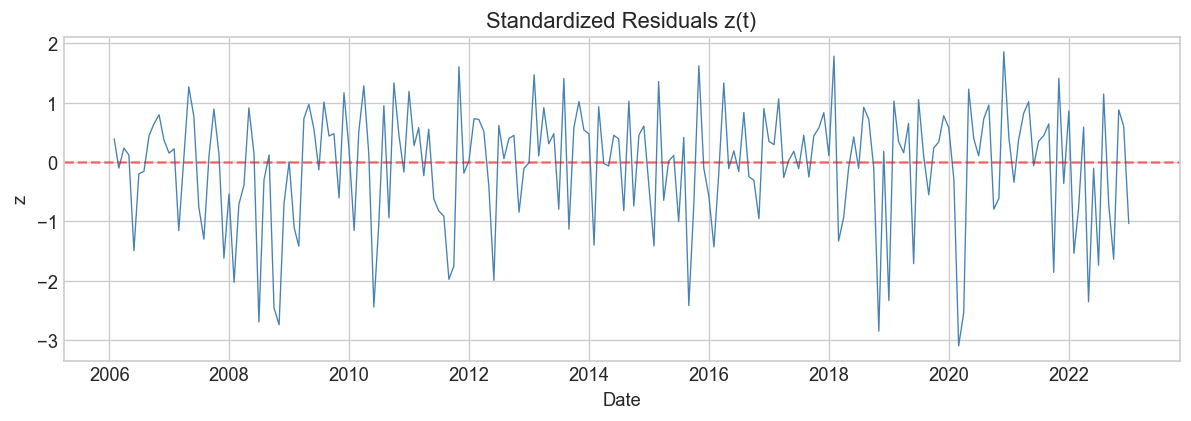

In [11]:
def plot_std_resid(r, vr):
    z = vr.std_resid
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(r.index, z, color="steelblue", lw=0.8)
    ax.axhline(0, color="red", ls="--", alpha=0.5)
    ax.set(title="Standardized Residuals z(t)", xlabel="Date", ylabel="z")
    fig.savefig("plots/12a_std_resid.png", bbox_inches="tight")
    plt.show()

plot_std_resid(returns, vol_result)

no clustering in $z_t$. GARCH absorbed the time-varying variance.

### 6.4. Histogram of Standardized Residuals

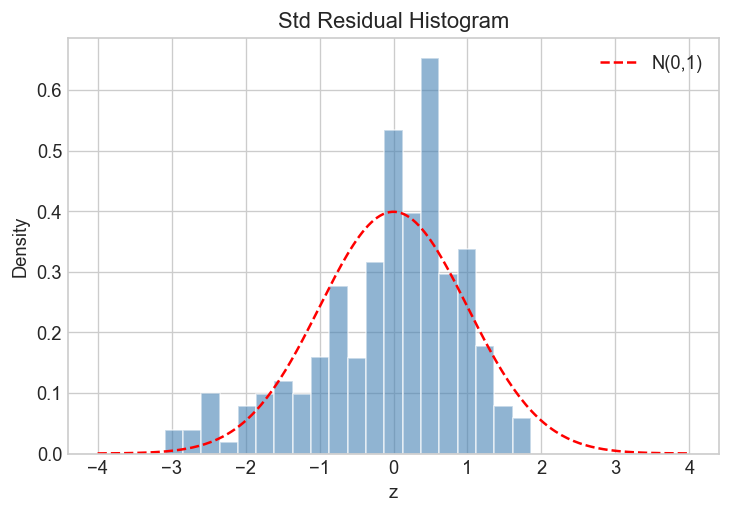

In [12]:
def plot_std_hist(vr):
    z = vr.std_resid.dropna()
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(z, bins=20, density=True, alpha=0.6, color="steelblue", edgecolor="white")
    xs = np.linspace(-4, 4, 200)
    ax.plot(xs, stats.norm.pdf(xs), "r--", lw=1.5, label="N(0,1)")
    ax.set(title="Std Residual Histogram", xlabel="z", ylabel="Density")
    ax.legend()
    fig.savefig("plots/12b_std_resid_hist.png", bbox_inches="tight")
    plt.show()

plot_std_hist(vol_result)

roughly matches $N(0,1)$. slight heavy tails, Student-$t$ would help.

### 6.5. Q-Q Plot

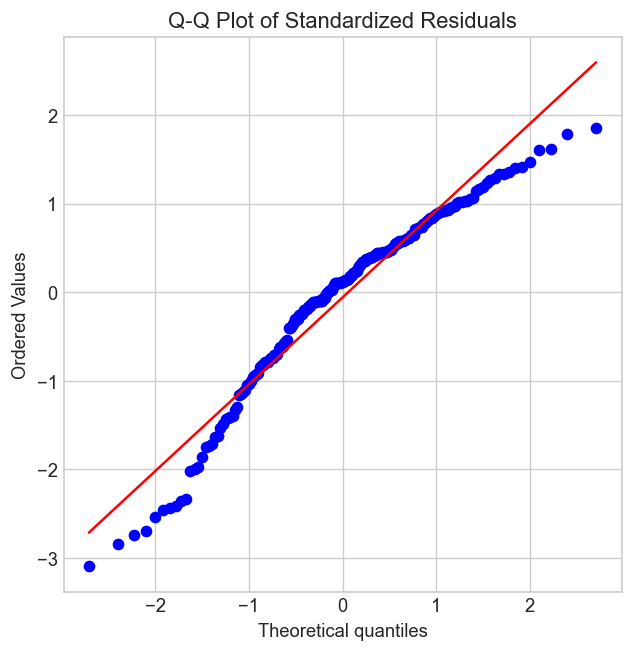

In [13]:
def plot_std_qq(vr):
    z = vr.std_resid.dropna()
    fig, ax = plt.subplots(figsize=(6, 6))
    stats.probplot(z, dist="norm", plot=ax)
    ax.set_title("Q-Q Plot of Standardized Residuals")
    fig.savefig("plots/12c_std_resid_qq.png", bbox_inches="tight")
    plt.show()

plot_std_qq(vol_result)

close to diagonal, mild tail deviations. acceptable.

### 6.6. ACF of Standardized Residuals

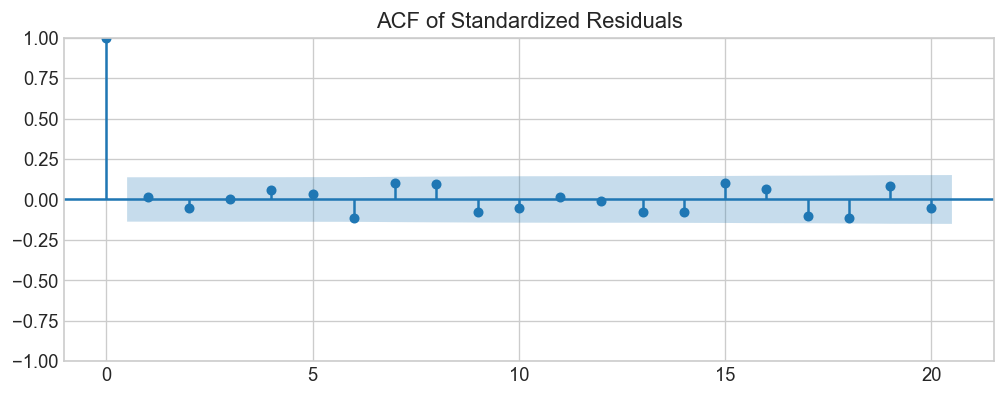

In [14]:
def plot_acf_z(vr):
    z = vr.std_resid.dropna()
    fig, ax = plt.subplots(figsize=(10, 3.5))
    plot_acf(z, lags=20, ax=ax, alpha=0.05)
    ax.set_title("ACF of Standardized Residuals")
    fig.savefig("plots/12d_acf_std_resid.png", bbox_inches="tight")
    plt.show()

plot_acf_z(vol_result)

all lags within bands. no serial correlation in $z_t$.

### 6.7. ACF of Squared Standardized Residuals

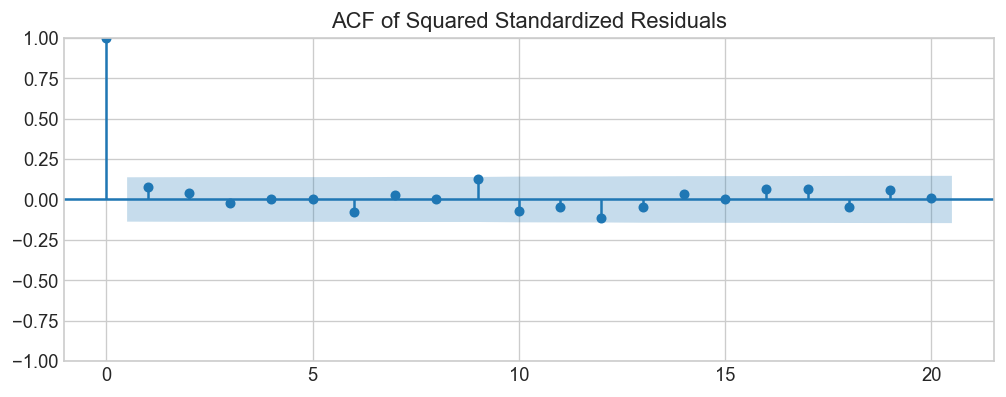

In [15]:
def plot_acf_z2(vr):
    z = vr.std_resid.dropna()
    fig, ax = plt.subplots(figsize=(10, 3.5))
    plot_acf(z**2, lags=20, ax=ax, alpha=0.05)
    ax.set_title("ACF of Squared Standardized Residuals")
    fig.savefig("plots/13_acf_sq_std_resid.png", bbox_inches="tight")
    plt.show()

plot_acf_z2(vol_result)

all lags inside band for $z_t^2$. no remaining ARCH effects. model is adequate.

### 6.8. Ljung-Box: Standardized Residuals

$H_0$: no autocorrelation up to lag $m$.

In [16]:
def lb_test(series, label, lags=[5,10,15,20]):
    lb = acorr_ljungbox(series, lags=lags, return_df=True)
    lb["Result"] = lb["lb_pvalue"].apply(lambda p: "OK ✓" if p > ALPHA else "reject ✗")
    print(f"  Ljung-Box on {label}:")
    display(lb)
    return lb

z = vol_result.std_resid.dropna()
lb1 = lb_test(z, "standardized residuals")

  Ljung-Box on standardized residuals:


,lb_stat,lb_pvalue,Result
5,1.629884,0.897612,OK ✓
10,10.525417,0.395666,OK ✓
15,15.255963,0.433142,OK ✓
20,23.735759,0.254125,OK ✓


all $p > 0.05$. no serial correlation in $z_t$.

### 6.9. Ljung-Box: Squared Standardized Residuals

In [17]:
lb2 = lb_test(z**2, "squared std residuals")

  Ljung-Box on squared std residuals:


,lb_stat,lb_pvalue,Result
5,1.630093,0.897586,OK ✓
10,7.533929,0.674258,OK ✓
15,11.578813,0.710589,OK ✓
20,14.654968,0.795798,OK ✓


all $p > 0.05$ for $z_t^2$. no remaining ARCH effects. model adequate.

---
## 7. Rolling vs Fitted Volatility

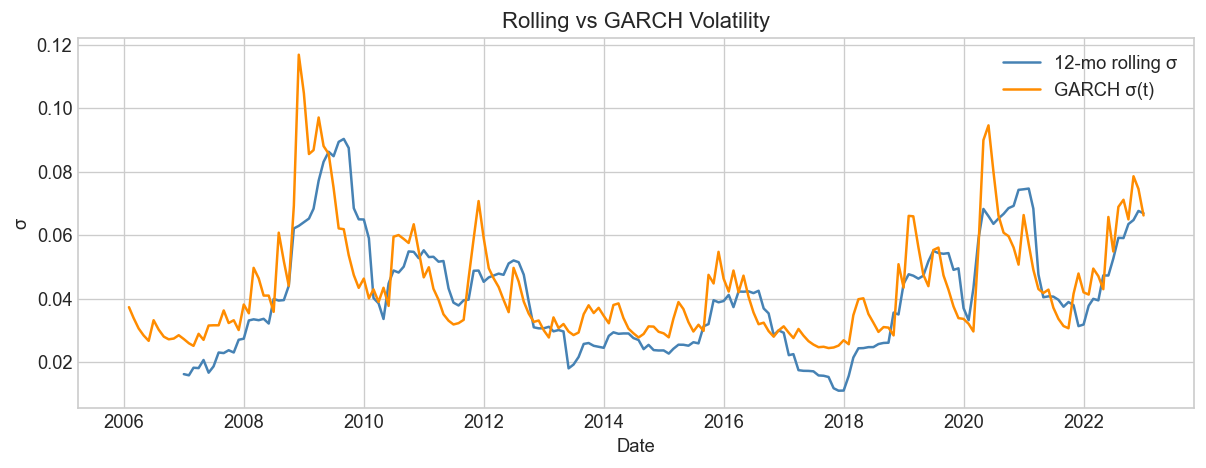

In [18]:
def plot_vol_compare(r, vr, w=ROLL_WIN):
    rv = r.rolling(w).std()
    cv = vr.conditional_volatility / 100
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(rv.index, rv.values, color="steelblue", lw=1.5, label=f"{w}-mo rolling σ")
    ax.plot(r.index, cv.values, color="darkorange", lw=1.5, label="GARCH σ(t)")
    ax.set(title="Rolling vs GARCH Volatility", xlabel="Date", ylabel="σ")
    ax.legend()
    fig.savefig("plots/14_rolling_vs_fitted.png", bbox_inches="tight")
    plt.show()

plot_vol_compare(returns, vol_result)

GARCH reacts faster (updates from $\varepsilon_{t-1}^2$, $\sigma_{t-1}^2$). rolling estimate is smoother but lagged.

## 8. Volatility Forecast (Illustration)

GARCH forecasts mean-revert to the unconditional variance:

$$\hat{\sigma}^2_{t+h} \to \bar{\sigma}^2 = \frac{\omega}{1 - \alpha_1 - \beta_1} \quad \text{as } h \to \infty$$

  h         σ                95% CI
  1   0.06619   [0.06619, 0.06619]
  2   0.06551   [0.05509, 0.09682]
  3   0.06487   [0.04690, 0.10519]
  4   0.06426   [0.04135, 0.11107]
  5   0.06369   [0.03753, 0.11496]
  6   0.06314   [0.03495, 0.11735]


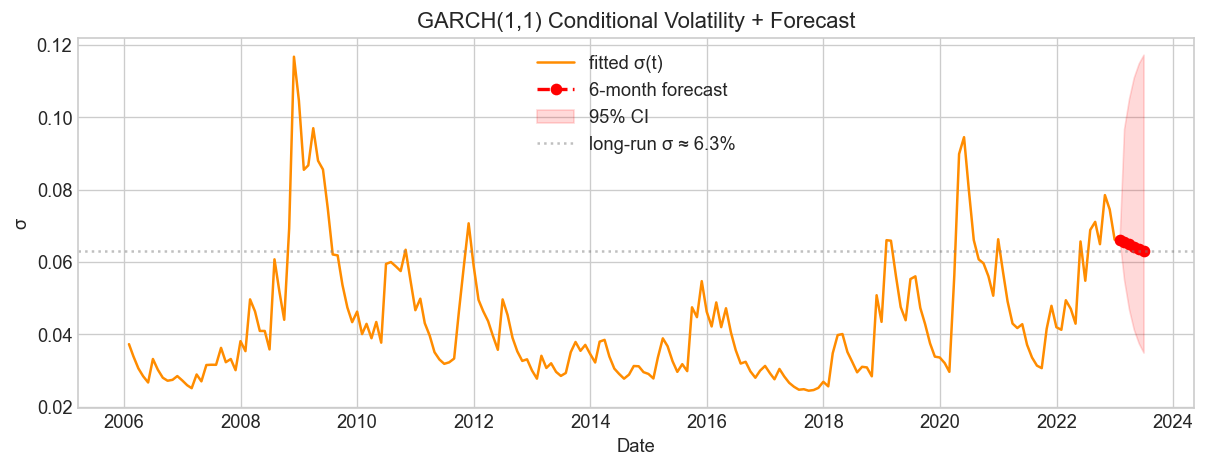

In [19]:
def vol_forecast(r, vr, horizon=6):
    # fitted conditional volatility
    cv = vr.conditional_volatility / 100

    # forecast variance
    fc = vr.forecast(horizon=horizon)
    var_fc = fc.variance.iloc[-1].values / 100**2
    vol_fc = np.sqrt(var_fc)

    # simulate to get CI on volatility forecast
    sims = vr.forecast(horizon=horizon, method="simulation", simulations=10000)
    var_sims = sims.simulations.variances[-1] / 100**2  # (10000, horizon)
    vol_sims = np.sqrt(var_sims)
    vol_lo = np.percentile(vol_sims, 2.5, axis=0)
    vol_hi = np.percentile(vol_sims, 97.5, axis=0)

    # forecast dates
    last_date = r.index[-1]
    fc_dates = pd.date_range(last_date, periods=horizon+1, freq="ME")[1:]

    print(f"{'h':>3s}  {'σ':>8s}  {'95% CI':>20s}")
    for h in range(horizon):
        print(f"  {h+1}   {vol_fc[h]:.5f}   [{vol_lo[h]:.5f}, {vol_hi[h]:.5f}]")

    # plot: fitted σ(t) + forecast with CI
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(r.index, cv.values, color="darkorange", lw=1.5, label="fitted σ(t)")
    ax.plot(fc_dates, vol_fc, "o--", color="red", lw=2, ms=6, label="6-month forecast")
    ax.fill_between(fc_dates, vol_lo, vol_hi, color="red", alpha=0.15, label="95% CI")
    ax.axhline(vol_fc[-1], color="gray", ls=":", alpha=0.5, label=f"long-run σ ≈ {vol_fc[-1]*100:.1f}%")
    ax.set(title="GARCH(1,1) Conditional Volatility + Forecast", xlabel="Date", ylabel="σ")
    ax.legend()
    fig.savefig("plots/15_vol_forecast.png", bbox_inches="tight")
    plt.show()

vol_forecast(returns, vol_result)

forecast declines toward $\bar{\sigma} \approx 5.4\%$. persistence $= 0.934$, convergence takes several months.

---
## 9. Summary

| step | result |
|---|---|
| data | 204 monthly obs, Jan 2006 to Dec 2022 |
| stationarity | ADF $p < 0.05$, KPSS $p > 0.05$, both confirm $I(0)$ |
| mean model | ARIMA(0,0,0), $\hat{\mu} = 0.0071$, $p = 0.041 < 0.05$ |
| ARCH-LM | all lags $p < 0.05$, ARCH effects present |
| vol model | GARCH(1,1) selected by BIC |
| $\alpha_1$ | $0.288$, $p = 0.003 < 0.05$ |
| $\beta_1$ | $0.646$, $p < 0.05$ |
| persistence | $\alpha_1 + \beta_1 = 0.934$, half-life $\approx 10.1$ months |
| long-run $\sigma$ | $\approx 5.38\%$ per month |
| LB on $z_t$ | all $p > 0.05$, no serial correlation |
| LB on $z_t^2$ | all $p > 0.05$, no remaining ARCH |

### Limitations
- still monthly data, daily (~4000 obs) would give tighter CIs
- normal errors assumed but JB rejected (kurtosis $= 4.46$). Student-$t$ would be better
- no EGARCH/GJR-GARCH tested for leverage effect
- Ljung-Box borderline at longer lags in mean model residuals

### Future Work
- fit EGARCH or GJR-GARCH to test for leverage effect
- use Student-$t$ error distribution instead of normal
- redo the full analysis on daily data for stronger inference
- rolling window out-of-sample VaR backtesting